In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

# Load and filter data
df = pd.read_csv('house_prices.csv')  # Update path
df.fillna({'price': 0, 'bedrooms': 0}, inplace=True) # replace NaN to 0 in price and bedrooms
mask = df['bedrooms'].isin([3, 4, 5])
filtered_df = df[mask]

In [75]:
# Features and target
X = filtered_df[['bedrooms']] # Feature: bedrooms
y = filtered_df['price']      # Target: price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42) #X_train=70%bedroom,X_test=30%bedroom,y_train=70%price,y_test=30% price


In [76]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Model R² Score: {model.score(X_test, y_test):.2f}")

Model R² Score: 0.03


In [79]:
# Predict on test set
y_pred = model.predict(X_test)
print(f"First 5 predictions: {y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")

First 5 predictions: [493017.91934936 493017.91934936 763349.03512855 628183.47723896
 493017.91934936]
First 5 actual prices: [522500.  148612.5 409124.  800000.  275000. ]


In [80]:
# Calculate prediction errors
import numpy as np
errors = y_test.values - y_pred
print(f"First 5 prediction errors: {errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(errors)):.1f}")

First 5 prediction errors: [  29482.08065064 -344405.41934936 -354225.03512855  171816.52276104
 -218017.91934936]
Mean Absolute Error: 249886.4


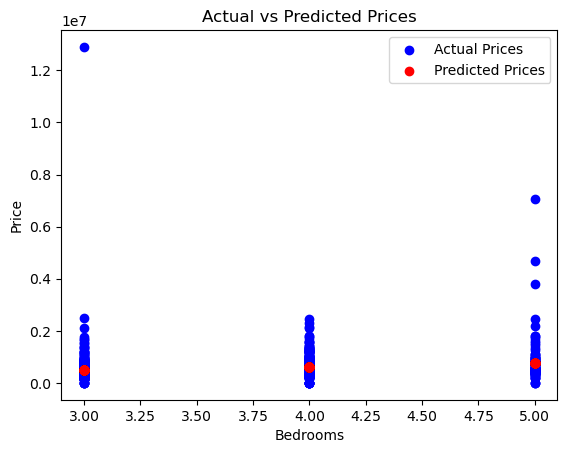

In [83]:
import matplotlib.pyplot as plt


# Plot actual vs predicted prices
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.scatter(X_test, y_pred, color='red', label='Predicted Prices')
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.savefig('ML_Basics/actual_vs_predicted.png')
